# Advanced Saturation Models — Milestone 7.4 (v0.6.0)

Antoine is accurate over a narrow band; extrapolating it to the critical point or to low reduced temperatures goes wrong. This milestone adds the **corresponding-states** saturation correlations (Riedel, Müller, RPM) that use $T_c$, $P_c$, $T_b$, and ω; the **Maxwell equal-area** construction (the thermodynamically exact saturation pressure of a cubic EOS); **boiling-temperature** inversion and the **Poynting** correction; and the **OL-family α** (VdWOL / RKOL / PROL), whose α reads the reduced saturation pressure — which is why it had to wait for this layer. Ref (4): Da Silva & Báez (1989); OL: Olivera et al. (1998).

## Setup (optional)

The cell below is **commented out by default**. Uncomment it if you want to use the latest `vle-thermo` released on PyPI instead of whatever version is currently installed in your kernel.

In [1]:
# Optional: pull the latest vle-thermo from PyPI.
# Uncomment if you want the newest released version instead of
# whatever is currently in your kernel. On the hosted hub this
# install is ephemeral — it vanishes when your session is culled.
# %pip install --upgrade vle-thermo

## Context — saturation pressure beyond Antoine

From [Chapter II](https://github.com/miguelju/vle/blob/main/docs/en/research-paper/chapter-2-vle-theory.md), the saturation (vapor) pressure $P^{sat}(T)$ is the backbone of low-pressure VLE. This milestone ports several models, all returning $P^{sat}$ in **kPa**:

| Model | Inputs | Note |
|---|---|---|
| Antoine | `[a1,a2,a3]` | $\ln(P/P_c)=a_1-a_2/(a_3+T)$; analytical $dP/dT$ |
| Riedel | $T_c,P_c,T_b$ | Riedel-criterion corresponding states |
| Müller | $T_c,P_c,T_b,\omega$ | reduced-property correlation |
| RPM | $T_c,P_c,T_b$ | Riedel-Plank-Miller |
| Maxwell | a cubic EOS | equal-fugacity on the EOS isotherm (exact) |

The **OL-family α** is special: $\alpha(T_r)=T_r\,(1+\mathrm{SumHk})$, where SumHk is a polynomial in $-\ln(P^{sat}_r/T_r)$ with family-specific coefficients (`clsQbicsPure.cls:268`). Because it reads the **reduced saturation pressure**, the OL α only makes sense once a saturation model exists — hence it lands here. In the engine the model is chosen per component via `Component.sat_model` (default Antoine); the binding `eos_alpha_ol` takes it explicitly.

## What was built in Milestone 7.4

Through `vle._engine`:

- `sat_psat(model, t, tc, pc, omega, tb, coeffs)` and `sat_reduced_psat(...)` — Riedel / Müller / RPM / Polynomial; `sat_d_psat_dt(...)` (analytical for Antoine, numerical otherwise).
- `sat_maxwell(eos, t, tc, pc, omega, coeffs)` — Maxwell equal-area saturation pressure for a cubic EOS.
- `boiling_temperature(model, p, …)` — invert $P^{sat}(T)=P$ (closed form for Antoine, Brent otherwise).
- `poynting_factor(p, psat, t, liquid_volume)`.
- `eos_alpha_ol` / `eos_d_alpha_d_tr_ol` — the OL-family α with an **analytical** dα/dTr (via the chain rule through $dP^{sat}/dT$).

## Worked example

Imports and n-pentane saturation data.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import vle._engine as e
%matplotlib inline

print('vle-thermo', e.version())

P = dict(tc=469.7, pc=3370.0, omega=0.252, tb=309.2)   # n-pentane
ANTOINE = [6.738, 3165.0, 0.0]                          # reduced Antoine fit

def psat(model, t, coeffs=None):
    return e.sat_psat(model, t, P['tc'], P['pc'], P['omega'], P['tb'], coeffs or [])

vle-thermo 0.6.0


### Saturation curves: Antoine vs corresponding-states models

All correlations are tuned to pass through 1 atm at the normal boiling point $T_b$; they diverge as you move away from it.

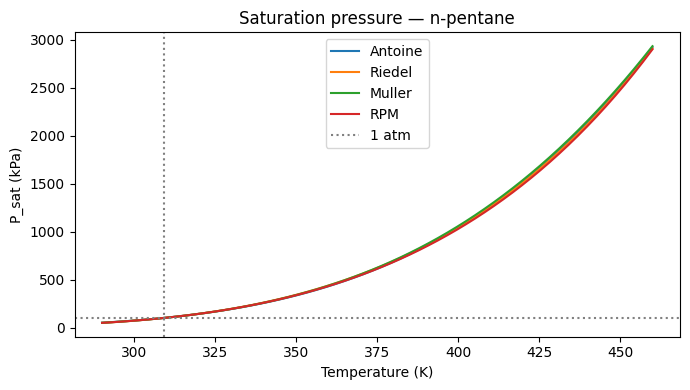

In [3]:
Ts = np.linspace(290.0, 460.0, 60)
models = [
    ('Antoine', e.SatPressureModel.Antoine, ANTOINE),
    ('Riedel',  e.SatPressureModel.Riedel,  None),
    ('Muller',  e.SatPressureModel.Muller,  None),
    ('RPM',     e.SatPressureModel.RPM,     None),
]
plt.figure(figsize=(7, 4))
for name, model, coeffs in models:
    plt.plot(Ts, [psat(model, t, coeffs) for t in Ts], label=name)
plt.axhline(101.325, ls=':', c='grey', label='1 atm')
plt.axvline(P['tb'], ls=':', c='grey')
plt.xlabel('Temperature (K)'); plt.ylabel('P_sat (kPa)')
plt.title('Saturation pressure — n-pentane'); plt.legend(); plt.tight_layout(); plt.show()

# Every corresponding-states model gives ~1 atm at Tb:
for _, model, _ in models[1:]:
    assert abs(psat(model, P['tb']) - 101.325) / 101.325 < 0.05

### Maxwell construction, boiling point, and Poynting

Maxwell finds the pressure where the cubic EOS's liquid and vapor roots have equal fugacity — the thermodynamically exact $P^{sat}$.

In [4]:
T = 350.0
pm = e.sat_maxwell(e.CubicEos.PR1976, T, P['tc'], P['pc'], P['omega'], ANTOINE)
pa = psat(e.SatPressureModel.Antoine, T, ANTOINE)
print(f'Maxwell (PR) P_sat = {pm:8.2f} kPa   Antoine P_sat = {pa:8.2f} kPa')

# Boiling temperature: invert P_sat(T) = P, then round-trip.
p_target = 200.0
tb = e.boiling_temperature(e.SatPressureModel.Antoine, p_target,
                           P['tc'], P['pc'], 0.0, 0.0, ANTOINE)
print(f'T_boil at {p_target} kPa = {tb:.2f} K  ->  P_sat(T_boil) = '
      f'{e.antoine_psat(tb, P["pc"], ANTOINE):.2f} kPa')
assert abs(e.antoine_psat(tb, P['pc'], ANTOINE) - p_target) / p_target < 1e-6

# Poynting factor for the compressed liquid (V_L = 116 cm3/mol).
for p in (pa, 1000.0, 5000.0):
    print(f'Poynting at P={p:7.1f} kPa (P_sat={pa:.1f}): {e.poynting_factor(p, pa, T, 116.0):.4f}')

Maxwell (PR) P_sat =   338.03 kPa   Antoine P_sat =   336.24 kPa
T_boil at 200.0 kPa = 330.99 K  ->  P_sat(T_boil) = 200.00 kPa
Poynting at P=  336.2 kPa (P_sat=336.2): 1.0000
Poynting at P= 1000.0 kPa (P_sat=336.2): 1.0268
Poynting at P= 5000.0 kPa (P_sat=336.2): 1.2043


### The OL-family α (saturation-coupled)

`eos_alpha_ol` evaluates $\alpha=T_r(1+\mathrm{SumHk})$ using the chosen saturation model. Here we use the Antoine model (so dα/dTr is fully analytical) and compare the OL α to plain Peng-Robinson.

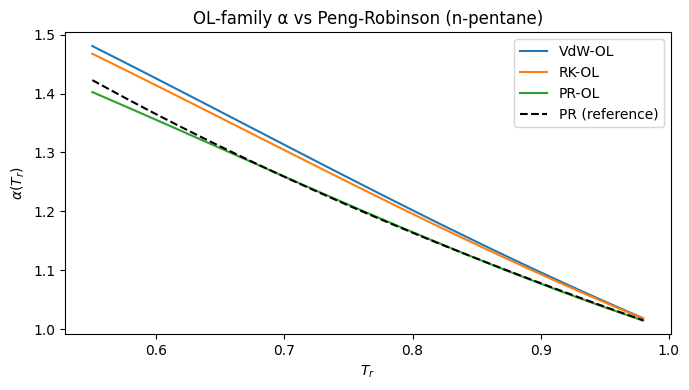

In [5]:
trs = np.linspace(0.55, 0.98, 50)
ol = {'VdW-OL': e.CubicEos.VdWOL1998, 'RK-OL': e.CubicEos.RKOL1998, 'PR-OL': e.CubicEos.PROL1998}
plt.figure(figsize=(7, 4))
for name, eos in ol.items():
    a = [e.eos_alpha_ol(eos, tr, P['tc'], P['pc'], P['omega'],
                        e.SatPressureModel.Antoine, 0.0, ANTOINE) for tr in trs]
    plt.plot(trs, a, label=name)
plt.plot(trs, [e.eos_alpha(e.CubicEos.PR1976, tr, P['omega']) for tr in trs],
         '--', c='k', label='PR (reference)')
plt.xlabel(r'$T_r$'); plt.ylabel(r'$\alpha(T_r)$')
plt.title('OL-family α vs Peng-Robinson (n-pentane)'); plt.legend(); plt.tight_layout(); plt.show()

# Analytical OL dα/dTr matches a central-difference oracle.
h, tr = 1e-6, 0.8
args = (P['tc'], P['pc'], P['omega'], e.SatPressureModel.Antoine, 0.0, ANTOINE)
ana = e.eos_d_alpha_d_tr_ol(e.CubicEos.PROL1998, tr, *args)
num = (e.eos_alpha_ol(e.CubicEos.PROL1998, tr + h, *args)
       - e.eos_alpha_ol(e.CubicEos.PROL1998, tr - h, *args)) / (2 * h)
assert abs((ana - num) / ana) < 1e-4

## Exercise 1 — boiling point vs pressure

Compute the Antoine boiling temperature of n-pentane at $P = 50, 100, 200, 500$ kPa and confirm each round-trips ($P^{sat}(T_{boil}) = P$). Fill in the `# TODO`.

In [6]:
pressures = [50.0, 100.0, 200.0, 500.0]
# TODO: for each p, compute tb = e.boiling_temperature(e.SatPressureModel.Antoine, p,
#       P['tc'], P['pc'], 0.0, 0.0, ANTOINE); print tb; assert the round-trip.


<details><summary>Solution</summary>

```python
for p in pressures:
    tb = e.boiling_temperature(e.SatPressureModel.Antoine, p, P['tc'], P['pc'], 0.0, 0.0, ANTOINE)
    back = e.antoine_psat(tb, P['pc'], ANTOINE)
    print(f'P={p:6.1f} kPa -> T_boil={tb:6.2f} K -> P_sat={back:6.1f} kPa')
    assert abs(back - p) / p < 1e-6
```
</details>

## Exercise 2 — Maxwell vs a correlation

Compare the **Maxwell** (PR EOS) saturation pressure to the **Riedel** correlation across $T = 320 \dots 440$ K, and plot the ratio $P^{Maxwell}/P^{Riedel}$. Where do they agree best?

In [7]:
Ts2 = np.linspace(320.0, 440.0, 25)
# TODO: build `ratio = [sat_maxwell(...) / psat(Riedel, t) for t in Ts2]` and plot it.


<details><summary>Solution</summary>

```python
ratio = [e.sat_maxwell(e.CubicEos.PR1976, t, P['tc'], P['pc'], P['omega'], ANTOINE)
         / psat(e.SatPressureModel.Riedel, t) for t in Ts2]
plt.figure(figsize=(7, 4))
plt.plot(Ts2, ratio)
plt.axhline(1.0, ls=':', c='grey')
plt.xlabel('Temperature (K)'); plt.ylabel('P_Maxwell / P_Riedel')
plt.title('Maxwell (PR) vs Riedel — n-pentane'); plt.tight_layout(); plt.show()
```
</details>

## References

- **(4)** Da Silva, F. A.; Báez, L. — Riedel / Müller / RPM / Antoine correlations and the Maxwell construction (`legacy/pascal/TERMOI.PAS`, `legacy/vb6/clsSatPressureSolver.cls`, `clsQbicsPure.cls`).
- Olivera et al. (1998) — the OL-family α (`clsQbicsPure.cls:268`).
- [Chapter II](https://github.com/miguelju/vle/blob/main/docs/en/research-paper/chapter-2-vle-theory.md) — VLE theory.
- [`MODERNIZATION_PLAN.md`](https://github.com/miguelju/vle/blob/main/MODERNIZATION_PLAN.md) — Phase 8 (saturation) notes.
- Three-parameter EOS + Chao-Seader: [`02c_three_param_eos.ipynb`](02c_three_param_eos.ipynb).